In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
iris = load_iris()
df = pd.DataFrame(data = iris.data, columns= iris.feature_names)
df['Species'] = iris.target
df['species_name'] = df['Species'].apply(lambda x: iris.target_names[x])

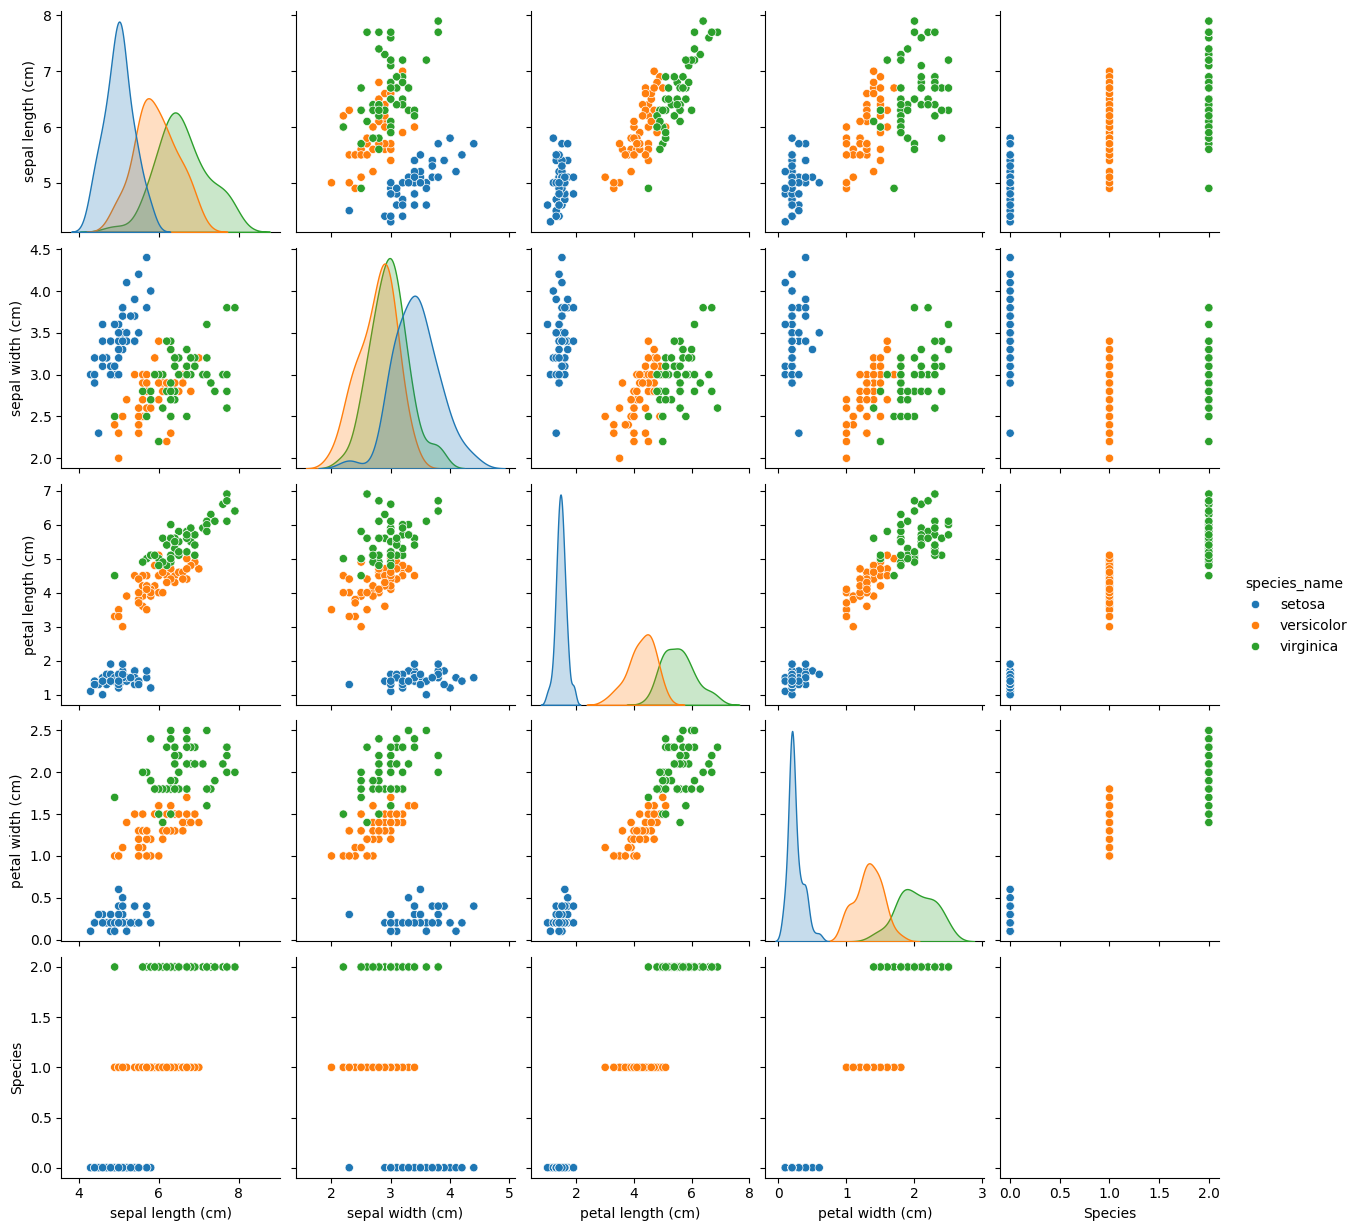

In [4]:
sns.pairplot(df, hue='species_name', diag_kind='kde')

In [5]:
x = df.iloc[:, :-2]
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state= 42)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = RandomForestClassifier(n_estimators= 100, random_state= 42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f} %")

Accuracy: 100.00 %


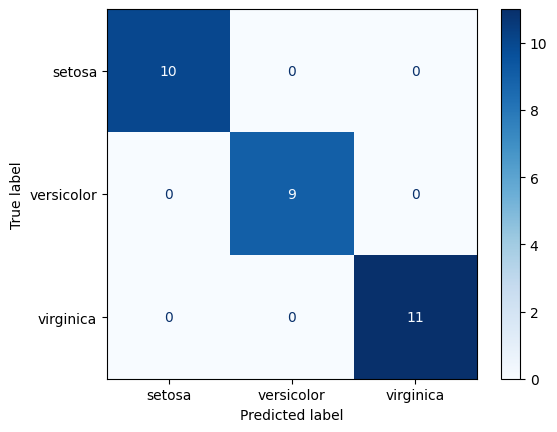

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=  model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels = iris.target_names)
disp.plot(cmap = "Blues")

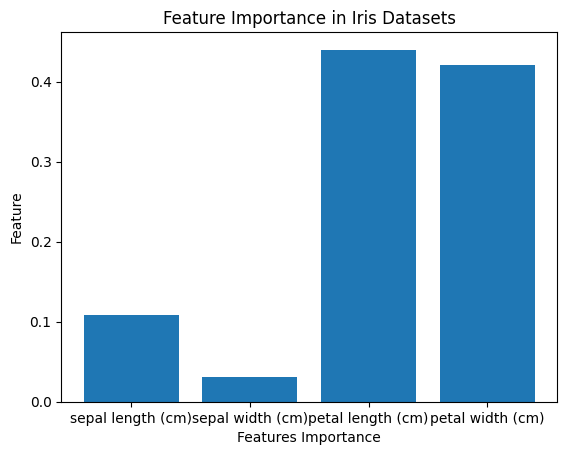

In [13]:
feature_importances = model.feature_importances_
feature = iris.feature_names
plt.bar(feature, feature_importances)
plt.xlabel('Features Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Iris Datasets')
plt.show()